# 08 - Model Comparison: Avaliação e Comparação Final

Avalia todos os modelos (popularidade, item-CF, user-CF, matrix factorization, NCF) no mesmo split de teste e gera o relatório/Model Card final. Ver `docs/NOTEBOOKS.md` (seção 8).

## 0. Configuração Inicial

In [1]:
import json
import pickle
import random
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import yaml

sys.path.insert(0, str(Path("..").resolve()))
from src.evaluation.metrics import (
    coverage_at_k,
    evaluate_recommendations,
    hit_rate_at_k,
    pairs_to_ground_truth,
)
from src.evaluation.ranking import recommendations_from_score_matrix
from src.models.ncf import NeuralCollaborativeFiltering, score_all_items

RANDOM_SEED = 42


def set_seed(seed: int) -> None:
    """Fixa a seed de aleatoriedade para reprodutibilidade."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


set_seed(RANDOM_SEED)

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
EVAL_DIR = MODELS_DIR / "evaluation"
PLOTS_DIR = Path("outputs/model_comparison/plots")
EVAL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

with open("../configs/model_config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)
K = config["evaluation"]["k"]

mlflow.set_tracking_uri(f"file:{(Path('..') / 'mlruns').resolve()}")
mlflow.set_experiment("model_comparison")

print(f"K={K}")

K=10


## 1. Carregamento dos Artefatos de Preprocessing

In [2]:
with open(PROCESSED_DIR / "vocabularies.pkl", "rb") as f:
    vocab = pickle.load(f)
with open(PROCESSED_DIR / "split_meta.json", encoding="utf-8") as f:
    split_meta = json.load(f)

interactions_prior = sp.load_npz(PROCESSED_DIR / "interactions_prior.npz")
test_pairs = pd.read_pickle(PROCESSED_DIR / "test_pairs.pkl")

n_users, n_items = interactions_prior.shape
test_ground_truth = pairs_to_ground_truth(test_pairs)
test_users = list(test_ground_truth.keys())

print(f"n_users={n_users:,} | n_items={n_items:,} | test_users={len(test_users):,}")

n_users=126,408 | n_items=3,000 | test_users=18,962


## 2. Geração de Recomendações no Teste, por Modelo

**Nota de escopo:** o user-based CF (notebook 05) avalia em amostra (3.000 usuários) por custo computacional da busca de vizinhos; os demais modelos avaliam a população completa de teste. Essa diferença é preservada aqui e reportada explicitamente no Model Card — não é uma limitação escondida.

In [3]:
def time_recommendations(fn, *args) -> tuple[dict, float]:
    """Mede o tempo de geracao de recomendacoes de um modelo.

    Args:
        fn: funcao que gera o dicionario de recomendacoes.
        *args: argumentos posicionais passados para fn.

    Returns:
        Tupla (recomendacoes, latencia_media_ms_por_usuario).
    """
    start = time.time()
    recommendations = fn(*args)
    elapsed_ms = (time.time() - start) * 1000
    return recommendations, elapsed_ms / max(len(recommendations), 1)

In [4]:
with open(MODELS_DIR / "baseline_popularity/ranking.pkl", "rb") as f:
    popularity_ranking = pickle.load(f)


def popularity_predict(users: list, ranking: np.ndarray, k: int) -> dict:
    top_k = ranking[:k].tolist()
    return {user_idx: top_k for user_idx in users}


popularity_recs, popularity_latency = time_recommendations(
    popularity_predict, test_users, popularity_ranking, K
)
print(f"popularity: {popularity_latency:.4f} ms/usuario")

popularity: 0.0001 ms/usuario


In [5]:
item_similarity = sp.load_npz(
    MODELS_DIR / "item_based_cf/item_similarity.npz"
).toarray()


def item_cf_predict(
    users: list, interactions: sp.csr_matrix, similarity: np.ndarray, k: int
) -> dict:
    scores = interactions[users].dot(similarity)
    return recommendations_from_score_matrix(users, scores, k)


item_cf_recs, item_cf_latency = time_recommendations(
    item_cf_predict, test_users, interactions_prior, item_similarity, K
)
print(f"item_based_cf: {item_cf_latency:.4f} ms/usuario")

item_based_cf: 0.0815 ms/usuario


In [6]:
with open(MODELS_DIR / "user_based_cf/knn_model.pkl", "rb") as f:
    user_cf_artifact = pickle.load(f)
knn_model = user_cf_artifact["model"]
pool_indices = user_cf_artifact["pool_indices"]

rng = np.random.default_rng(RANDOM_SEED)
eval_sample_size = min(config["user_based_cf"]["eval_sample_size"], len(test_users))
test_sample = rng.choice(test_users, size=eval_sample_size, replace=False)


def user_cf_predict(
    users: np.ndarray,
    interactions: sp.csr_matrix,
    pool_indices: np.ndarray,
    knn_model,
    k: int,
) -> dict:
    distances, neighbor_positions = knn_model.kneighbors(interactions[users])
    similarities = 1 - distances
    n_query, n_neighbors = neighbor_positions.shape
    rows = np.repeat(np.arange(n_query), n_neighbors)
    cols = neighbor_positions.flatten()
    weights = sp.csr_matrix(
        (similarities.flatten(), (rows, cols)), shape=(n_query, len(pool_indices))
    )
    scores = weights.dot(interactions[pool_indices]).toarray()
    return recommendations_from_score_matrix(list(users), scores, k)


user_cf_recs, user_cf_latency = time_recommendations(
    user_cf_predict, test_sample, interactions_prior, pool_indices, knn_model, K
)
print(f"user_based_cf (amostra): {user_cf_latency:.4f} ms/usuario")

user_based_cf (amostra): 0.5362 ms/usuario


In [7]:
user_factors = np.load(MODELS_DIR / "matrix_factorization/user_factors.npy")
item_factors = np.load(MODELS_DIR / "matrix_factorization/item_factors.npy")


def mf_predict(
    users: list, user_factors: np.ndarray, item_factors: np.ndarray, k: int
) -> dict:
    scores = user_factors[users] @ item_factors.T
    return recommendations_from_score_matrix(users, scores, k)


mf_recs, mf_latency = time_recommendations(
    mf_predict, test_users, user_factors, item_factors, K
)
print(f"matrix_factorization: {mf_latency:.4f} ms/usuario")

matrix_factorization: 0.0344 ms/usuario


In [8]:
with open(MODELS_DIR / "neural_network/metrics.json", encoding="utf-8") as f:
    ncf_metrics = json.load(f)
ncf_params = ncf_metrics["params"]

ncf_model = NeuralCollaborativeFiltering(
    n_users=n_users,
    n_items=n_items,
    embedding_dim=ncf_params["embedding_dim"],
    hidden_dims=tuple(ncf_params["hidden_dims"]),
)
ncf_model.load_state_dict(torch.load(MODELS_DIR / "neural_network/model.pt"))
ncf_model.eval()


def ncf_predict(model, users: list, n_items: int, k: int) -> dict:
    scores = score_all_items(model, users, n_items, batch_size=200)
    return recommendations_from_score_matrix(users, scores, k)


ncf_recs, ncf_latency = time_recommendations(
    ncf_predict, ncf_model, test_users, n_items, K
)
print(f"ncf: {ncf_latency:.4f} ms/usuario")

ncf: 4.9801 ms/usuario


## 3. Métricas Oficiais e Complementares por Modelo

In [9]:
def model_size_mb(*paths: Path) -> float:
    """Soma o tamanho em MB dos arquivos de artefato de um modelo."""
    return sum(p.stat().st_size for p in paths) / (1024 * 1024)


MODEL_SPECS = {
    "popularity": {
        "recs": popularity_recs,
        "ground_truth": test_ground_truth,
        "latency_ms": popularity_latency,
        "size_mb": model_size_mb(MODELS_DIR / "baseline_popularity/ranking.pkl"),
    },
    "item_based_cf": {
        "recs": item_cf_recs,
        "ground_truth": test_ground_truth,
        "latency_ms": item_cf_latency,
        "size_mb": model_size_mb(MODELS_DIR / "item_based_cf/item_similarity.npz"),
    },
    "user_based_cf": {
        "recs": user_cf_recs,
        "ground_truth": {u: test_ground_truth[u] for u in test_sample},
        "latency_ms": user_cf_latency,
        "size_mb": model_size_mb(MODELS_DIR / "user_based_cf/knn_model.pkl"),
    },
    "matrix_factorization": {
        "recs": mf_recs,
        "ground_truth": test_ground_truth,
        "latency_ms": mf_latency,
        "size_mb": model_size_mb(
            MODELS_DIR / "matrix_factorization/user_factors.npy",
            MODELS_DIR / "matrix_factorization/item_factors.npy",
        ),
    },
    "ncf": {
        "recs": ncf_recs,
        "ground_truth": test_ground_truth,
        "latency_ms": ncf_latency,
        "size_mb": model_size_mb(MODELS_DIR / "neural_network/model.pt"),
    },
}

rows = []
for name, spec in MODEL_SPECS.items():
    official = evaluate_recommendations(spec["recs"], spec["ground_truth"], K)
    rows.append(
        {
            "model": name,
            **official,
            "hit_rate_at_k": hit_rate_at_k(spec["recs"], spec["ground_truth"], K),
            "coverage_at_k": coverage_at_k(spec["recs"], n_items, K),
            "inference_latency_ms": spec["latency_ms"],
            "model_size_mb": spec["size_mb"],
        }
    )

comparison_df = pd.DataFrame(rows).set_index("model")
comparison_df

,precision_at_k,recall_at_k,ndcg_at_k,map_at_k,hit_rate_at_k,coverage_at_k,inference_latency_ms,model_size_mb
model,,,,,,,,
popularity,0.074734,0.093528,0.109690,0.052215,0.472893,0.003333,0.000053,0.023033
item_based_cf,0.129243,0.223619,0.217198,0.127443,0.672239,0.807333,0.081519,29.034459
user_based_cf,0.127000,0.205082,0.211693,0.122669,0.665667,0.729667,0.536170,4.314831
matrix_factorization,0.139848,0.201714,0.203246,0.113653,0.663590,0.215333,0.034449,74.048096
ncf,0.074982,0.092955,0.109306,0.051850,0.472629,0.014333,4.980132,31.880467


## 4. Comparação Visual

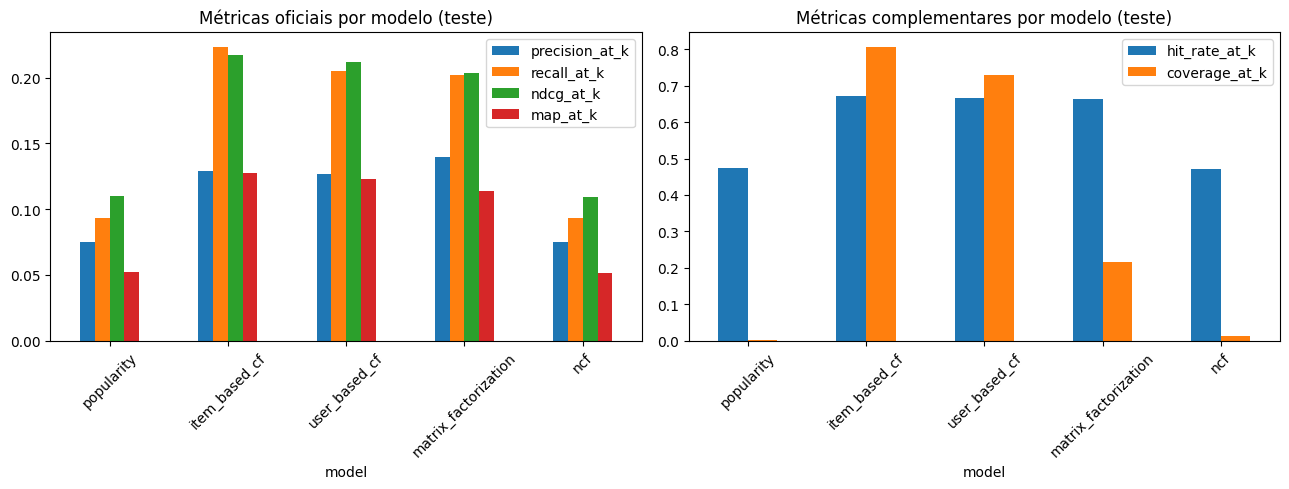

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
comparison_df[["precision_at_k", "recall_at_k", "ndcg_at_k", "map_at_k"]].plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Métricas oficiais por modelo (teste)")
axes[0].tick_params(axis="x", rotation=45)

comparison_df[["hit_rate_at_k", "coverage_at_k"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Métricas complementares por modelo (teste)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "metrics_comparison.png", dpi=150)
plt.show()

## 5. Critério de Promoção no Model Registry

In [11]:
baselines = comparison_df.drop(index="ncf")
ncf_row = comparison_df.loc["ncf"]

beats_recall = bool((ncf_row["recall_at_k"] > baselines["recall_at_k"]).all())
beats_ndcg = bool((ncf_row["ndcg_at_k"] > baselines["ndcg_at_k"]).all())

print(f"NCF supera todos os baselines em recall@k: {beats_recall}")
print(f"NCF supera todos os baselines em ndcg@k: {beats_ndcg}")

NCF supera todos os baselines em recall@k: False
NCF supera todos os baselines em ndcg@k: False


## 5.1 Registro de Todos os Modelos no MLflow Model Registry

A rede neural (`ncf_recommender`) já é registrada no notebook 07. Para que o
**melhor modelo de fato** (por `recall_at_k`) possa ser promovido a
`Production` — requisito do Tech Challenge —, os quatro baselines também
precisam existir como MLflow Models. Cada wrapper abaixo implementa a mesma
interface `predict(context, model_input)` (padrão Strategy), carregando seus
próprios artefatos via `load_context`.

In [12]:
class PopularityModel(mlflow.pyfunc.PythonModel):
    """Wrapper MLflow para o baseline de popularidade global."""

    def __init__(self, k: int) -> None:
        self.k = k

    def load_context(self, context: mlflow.pyfunc.PythonModelContext) -> None:
        with open(context.artifacts["ranking"], "rb") as f:
            self.ranking = pickle.load(f)

    def predict(self, context, model_input) -> list:
        users = list(model_input["user_idx"])
        top_k = self.ranking[: self.k].tolist()
        return [top_k for _ in users]


class ItemBasedCFModel(mlflow.pyfunc.PythonModel):
    """Wrapper MLflow para o item-based CF (similaridade de cosseno)."""

    def __init__(self, k: int) -> None:
        self.k = k

    def load_context(self, context: mlflow.pyfunc.PythonModelContext) -> None:
        self.similarity = sp.load_npz(context.artifacts["similarity"]).toarray()
        self.interactions = sp.load_npz(context.artifacts["interactions"])

    def predict(self, context, model_input) -> dict:
        users = list(model_input["user_idx"])
        scores = self.interactions[users].dot(self.similarity)
        return recommendations_from_score_matrix(users, scores, self.k)


class UserBasedCFModel(mlflow.pyfunc.PythonModel):
    """Wrapper MLflow para o user-based CF (KNN)."""

    def __init__(self, k: int) -> None:
        self.k = k

    def load_context(self, context: mlflow.pyfunc.PythonModelContext) -> None:
        with open(context.artifacts["knn"], "rb") as f:
            artifact = pickle.load(f)
        self.knn_model = artifact["model"]
        self.pool_indices = artifact["pool_indices"]
        self.interactions = sp.load_npz(context.artifacts["interactions"])

    def predict(self, context, model_input) -> dict:
        users = list(model_input["user_idx"])
        distances, neighbors = self.knn_model.kneighbors(self.interactions[users])
        similarities = 1 - distances
        n_query, n_neighbors = neighbors.shape
        rows = np.repeat(np.arange(n_query), n_neighbors)
        weights = sp.csr_matrix(
            (similarities.flatten(), (rows, neighbors.flatten())),
            shape=(n_query, len(self.pool_indices)),
        )
        scores = weights.dot(self.interactions[self.pool_indices]).toarray()
        return recommendations_from_score_matrix(users, scores, self.k)


class MatrixFactorizationModel(mlflow.pyfunc.PythonModel):
    """Wrapper MLflow para a fatoracao de matrizes (SVD)."""

    def __init__(self, k: int) -> None:
        self.k = k

    def load_context(self, context: mlflow.pyfunc.PythonModelContext) -> None:
        self.user_factors = np.load(context.artifacts["user_factors"])
        self.item_factors = np.load(context.artifacts["item_factors"])

    def predict(self, context, model_input) -> dict:
        users = list(model_input["user_idx"])
        scores = self.user_factors[users] @ self.item_factors.T
        return recommendations_from_score_matrix(users, scores, self.k)

C:\Users\willi\OneDrive\Documentos\Estudos\Python\big-data-challenge-fiap\big-data-challenge-fiap\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
C:\Users\willi\OneDrive\Documentos\Estudos\Python\big-data-challenge-fiap\big-data-challenge-fiap\.venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
C:\Users\willi\OneDrive\Documentos\Estudos\Python\big-data-challenge-fiap\big-data-challenge-fiap\.venv\Lib\site-packages\mlflow\pyfunc\utils\data

In [13]:
REGISTRY_SPECS = {
    "popularity": (
        PopularityModel(k=K),
        {"ranking": str(MODELS_DIR / "baseline_popularity/ranking.pkl")},
    ),
    "item_based_cf": (
        ItemBasedCFModel(k=K),
        {
            "similarity": str(MODELS_DIR / "item_based_cf/item_similarity.npz"),
            "interactions": str(PROCESSED_DIR / "interactions_prior.npz"),
        },
    ),
    "user_based_cf": (
        UserBasedCFModel(k=K),
        {
            "knn": str(MODELS_DIR / "user_based_cf/knn_model.pkl"),
            "interactions": str(PROCESSED_DIR / "interactions_prior.npz"),
        },
    ),
    "matrix_factorization": (
        MatrixFactorizationModel(k=K),
        {
            "user_factors": str(MODELS_DIR / "matrix_factorization/user_factors.npy"),
            "item_factors": str(MODELS_DIR / "matrix_factorization/item_factors.npy"),
        },
    ),
}

registered_model_names = {name: f"{name}_recommender" for name in REGISTRY_SPECS}
registered_model_names["ncf"] = "ncf_recommender"

for name, (python_model, artifacts) in REGISTRY_SPECS.items():
    with mlflow.start_run(run_name=f"register_{name}"):
        mlflow.pyfunc.log_model(
            artifact_path="model",
            python_model=python_model,
            artifacts=artifacts,
            registered_model_name=registered_model_names[name],
        )

print(f"Modelos registrados: {list(registered_model_names.values())}")

2026/06/21 18:55:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/06/21 18:55:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Successfully registered model 'popularity_recommender'.
Created version '1' of model 'popularity_recommender'.


2026/06/21 18:56:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/06/21 18:56:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

Successfully registered model 'user_based_cf_recommender'.
Created version '1' of model 'user_based_cf_recommender'.


2026/06/21 18:56:28 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


2026/06/21 18:56:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Successfully registered model 'matrix_factorization_recommender'.
Created version '1' of model 'matrix_factorization_recommender'.


Modelos registrados: ['popularity_recommender', 'item_based_cf_recommender', 'user_based_cf_recommender', 'matrix_factorization_recommender', 'ncf_recommender']


In [14]:
client = mlflow.tracking.MlflowClient()
best_model = comparison_df["recall_at_k"].idxmax()

for name, registry_name in registered_model_names.items():
    versions = client.search_model_versions(f"name='{registry_name}'")
    latest_version = max(int(v.version) for v in versions)
    stage = "Production" if name == best_model else "Staging"
    client.transition_model_version_stage(registry_name, latest_version, stage)
    print(f"{registry_name} versao {latest_version} -> estagio: {stage}")

C:\Users\willi\AppData\Local\Temp\ipykernel_28800\738841339.py:8: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(registry_name, latest_version, stage)


popularity_recommender versao 1 -> estagio: Staging
item_based_cf_recommender versao 1 -> estagio: Production


user_based_cf_recommender versao 1 -> estagio: Staging
matrix_factorization_recommender versao 1 -> estagio: Staging


ncf_recommender versao 3 -> estagio: Staging


## 6. Persistência e Rastreamento no MLflow

In [15]:
comparison_df.to_csv(EVAL_DIR / "metrics_comparison.csv")

with mlflow.start_run(run_name="model_comparison_v1"):
    mlflow.log_param("k", K)
    mlflow.log_param("dataset_hash", split_meta["dataset_hash"])
    mlflow.log_param("model_promoted_to_production", best_model)
    for name, row in comparison_df.iterrows():
        mlflow.log_metrics({f"{name}_{col}": val for col, val in row.items()})
    mlflow.log_artifact(str(EVAL_DIR / "metrics_comparison.csv"))
    mlflow.log_artifact(str(PLOTS_DIR / "metrics_comparison.png"))

print("Comparação final registrada no MLflow.")

Comparação final registrada no MLflow.


## 7. Model Card

In [16]:
model_card = f"""# Model Card - Sistema de Recomendacao Instacart

## Visao Geral

Comparacao de 5 modelos de recomendacao de produtos (top-{K}) avaliados no
split de teste interno derivado do dataset Instacart. Catalogo restrito aos
{n_items} produtos mais comprados (ver `docs/NOTEBOOKS.md`, secao "Escopo de
Catalogo"). Dataset hash: `{split_meta["dataset_hash"][:16]}...`.

## Metricas (split de teste)

{comparison_df.round(4).to_markdown()}

## Decisao de Promocao

- NCF supera todos os baselines em recall@k: {beats_recall}
- NCF supera todos os baselines em ndcg@k: {beats_ndcg}
- Modelo com melhor recall@k nesta rodada: **{best_model}**
- `{registered_model_names[best_model]}` promovido a **Production** no
  MLflow Model Registry; os demais modelos, incluindo `ncf_recommender`,
  permanecem em **Staging**.

## Limitacoes e Vieses

1. **Catalogo restrito**: avaliacao limitada aos top-{n_items} produtos por
   volume de compras (cobertura de {split_meta["catalog_coverage"]:.1%} do
   volume total). Produtos de nicho fora desse conjunto nunca sao
   recomendados nem avaliados.
2. **Amostragem no user-based CF**: por custo computacional da busca de
   vizinhos, o user-based CF foi avaliado em uma amostra de
   {len(test_sample):,} usuarios de teste, nao na populacao completa como os
   demais modelos — os valores nao sao estritamente comparaveis ponto a
   ponto, apenas direcionalmente.
3. **Negative sampling do NCF sem deduplicacao exaustiva**: a amostragem
   uniforme de negativos nao verifica exaustivamente se o item sorteado ja
   foi comprado pelo usuario, introduzindo ruido controlado no sinal de
   treino. Amostragem ponderada por popularidade foi testada e descartada
   (ver `docs/NOTEBOOKS.md`, secao 7.3): nesse dataset, com forte vies de
   recompra, ela penalizava justamente os itens mais relevantes.
4. **Vies de popularidade**: todos os modelos tendem a favorecer produtos de
   alta frequencia (coverage@k tipicamente baixo frente ao catalogo total),
   refletindo o proprio comportamento de recompra do dataset Instacart.
5. **Orcamento de treino do NCF**: treinado em CPU com early stopping
   (paciencia configurada em `configs/model_config.yaml`); mais epocas ou
   ajuste fino de hiperparametros podem alterar a posicao relativa do NCF
   frente aos baselines classicos.

## Recomendacao

Modelo recomendado para producao nesta rodada: **{best_model}**, promovido a
`Production` no MLflow Model Registry (`{registered_model_names[best_model]}`).
O `ncf_recommender` (modelo principal exigido em PyTorch) permanece em
`Staging` e pode ser promovido em rodadas futuras caso supere o desempenho
atual dos baselines classicos.
"""

with open(MODELS_DIR / "MODEL_CARD.md", "w", encoding="utf-8") as f:
    f.write(model_card)

print(model_card)

# Model Card - Sistema de Recomendacao Instacart

## Visao Geral

Comparacao de 5 modelos de recomendacao de produtos (top-10) avaliados no
split de teste interno derivado do dataset Instacart. Catalogo restrito aos
3000 produtos mais comprados (ver `docs/NOTEBOOKS.md`, secao "Escopo de
Catalogo"). Dataset hash: `c3fda3f4a8d64ffd...`.

## Metricas (split de teste)

| model                |   precision_at_k |   recall_at_k |   ndcg_at_k |   map_at_k |   hit_rate_at_k |   coverage_at_k |   inference_latency_ms |   model_size_mb |
|:---------------------|-----------------:|--------------:|------------:|-----------:|----------------:|----------------:|-----------------------:|----------------:|
| popularity           |           0.0747 |        0.0935 |      0.1097 |     0.0522 |          0.4729 |          0.0033 |                 0.0001 |          0.023  |
| item_based_cf        |           0.1292 |        0.2236 |      0.2172 |     0.1274 |          0.6722 |          0.8073 |            